11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.9496 - loss: 0.1697 - val_accuracy: 0.9786 - val_loss: 0.0657
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9821 - loss: 0.0589 - val_accuracy: 0.9805 - val_loss: 0.0597
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9883 - loss: 0.0387 - val_accuracy: 0.9836 - val_loss: 0.0460
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9913 - loss: 0.0276 - val_accuracy: 0.9846 - val_loss: 0.0480
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9936 - loss: 0.0202 - val_accuracy: 0.9852 - val_loss: 0.0443
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9852 - loss: 0.0443
WITHOUT TUNING Accuracy: 0.9851999878883362


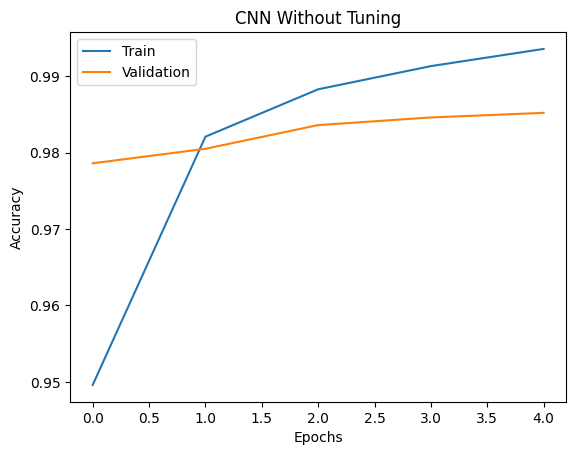

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Build CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history1 = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluate
loss1, acc1 = model.evaluate(x_test, y_test)
print("WITHOUT TUNING Accuracy:", acc1)

# Graph
plt.figure()
plt.plot(history1.history['accuracy'], label='Train')
plt.plot(history1.history['val_accuracy'], label='Validation')
plt.title("CNN Without Tuning")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 38ms/step - accuracy: 0.9582 - loss: 0.1369 - val_accuracy: 0.9859 - val_loss: 0.0451
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9861 - loss: 0.0442 - val_accuracy: 0.9879 - val_loss: 0.0326
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.9908 - loss: 0.0305 - val_accuracy: 0.9903 - val_loss: 0.0287
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.9926 - loss: 0.0232 - val_accuracy: 0.9894 - val_loss: 0.0316
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9943 - loss: 0.0170 - val_accuracy: 0.9906 - val_loss: 0.0299
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.9918 - val_loss: 0.0289
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9966 - loss: 0.0105 - val_accuracy: 0.9902 - val_loss: 0.0324
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9966 - loss: 0

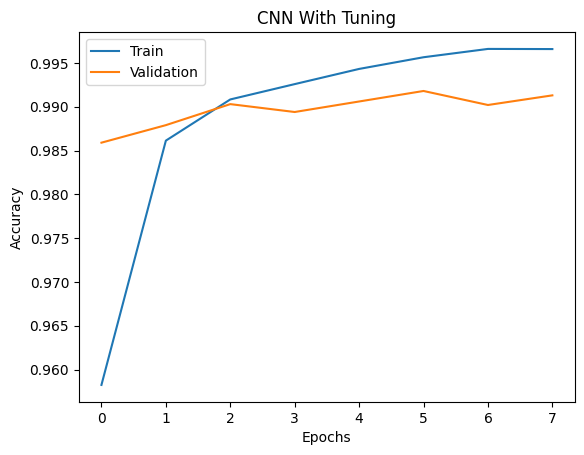

In [2]:
# Tuned CNN Model

model2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Train
history2 = model2.fit(x_train, y_train, epochs=8, batch_size=32,
                      validation_data=(x_test, y_test))

# Evaluate
loss2, acc2 = model2.evaluate(x_test, y_test)
print("WITH TUNING Accuracy:", acc2)

# Graph
plt.figure()
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Validation')
plt.title("CNN With Tuning")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
